In [25]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import matplotlib.pyplot as plt

In [26]:
# Define objective function for c=1.5
def f_rosenbrock(theta, c=1.5):
    """
    Rosenbrock 1D function:
    f(theta) = (1 - theta)^2 + c*(theta^2 - 1)^2
    """
    return (1 - theta)**2 + c * (theta**2 - 1)**2

def extract_params(filename):
    """Extract parameters from filename"""

    # For discrete files: c_X.X_results_initial_theta_Y_lr_Z_beta1_W_beta2_V.csv
    match_discrete = re.search(
        r'c_([\d.]+)_results_initial_theta_([-\d.]+)_lr_([\d.]+)_beta1_([\d.]+)_beta2_([\d.]+)\.csv',
        filename
    )
    if match_discrete:
        return {
            'c': float(match_discrete.group(1)),
            'initial_theta': float(match_discrete.group(2)),
            'initial_velocity': None,
            'lr': float(match_discrete.group(3)),
            'beta1': float(match_discrete.group(4)),
            'beta2': float(match_discrete.group(5))
        }

    # For 2nd order: second_order_c_X.X_initial_theta_Y_initial_velocity_Z_lr_W_beta1_V_beta2_U.csv
    match_2nd_order = re.search(
        r'second_order_c_([\d.]+)_initial_theta_([-\d.]+)_initial_velocity_([-\d.]+)_lr_([\d.]+)_beta1_([\d.]+)_beta2_([\d.]+)\.csv',
        filename
    )
    if match_2nd_order:
        return {
            'c': float(match_2nd_order.group(1)),
            'initial_theta': float(match_2nd_order.group(2)),
            'initial_velocity': float(match_2nd_order.group(3)),
            'lr': float(match_2nd_order.group(4)),
            'beta1': float(match_2nd_order.group(5)),
            'beta2': float(match_2nd_order.group(6))
        }

    # For 1st order: first_order_c_X.X_initial_theta_Y_initial_velocity_Z_lr_W_beta1_V_beta2_U.csv
    match_1st_order = re.search(
        r'first_order_c_([\d.]+)_initial_theta_([-\d.]+)_initial_velocity_([-\d.]+)_lr_([\d.]+)_beta1_([\d.]+)_beta2_([\d.]+)\.csv',
        filename
    )
    if match_1st_order:
        return {
            'c': float(match_1st_order.group(1)),
            'initial_theta': float(match_1st_order.group(2)),
            'initial_velocity': float(match_1st_order.group(3)),  # usually 0.0 for 1st order
            'lr': float(match_1st_order.group(4)),
            'beta1': float(match_1st_order.group(5)),
            'beta2': float(match_1st_order.group(6))
        }

    return None

def compute_rho(alpha, beta1, beta2):
    term1 = alpha
    term2 = alpha**2 / (1 - beta1)**2
    term3 = alpha / (1 - beta2)
    rho = max(term1, term2, term3)
    return rho, term1, term2, term3

def exp_plus_floor(t, A, rho, B):
    return A * np.exp(-rho * t) + B

In [27]:
# Configuration: theta_initial = -1.5, fixed betas
target_initial_theta = -1.5
target_initial_velocity = 1.0
target_beta1 = 0.99
target_beta2 = 0.999
c_value = 4

# Directories
results_dir = Path("results")
results_1st_order_dir = Path("results_1rst_order")
results_2nd_order_dir = Path("results_2nd_order")

In [28]:
# Read ALL discrete files
discrete_data_dict = {}
discrete_files = list(results_dir.glob("*.csv"))

for csv_file in discrete_files:
    params = extract_params(str(csv_file))
    if (params and
        params['c'] == c_value and
        params['initial_theta'] == target_initial_theta and
        params['beta1'] == target_beta1 and
        params['beta2'] == target_beta2):
        lr = params['lr']
        discrete_data_dict[lr] = pd.read_csv(csv_file)
        print(f"Discrete file found: {csv_file.name}, lr={lr}")


# Read 2nd order files
results_2nd_order = {}
continuous_2nd_files = list(results_2nd_order_dir.glob("*.csv"))

for csv_file in continuous_2nd_files:
    params = extract_params(str(csv_file))
    if (params and
        params['c'] == c_value and
        params['initial_theta'] == target_initial_theta and
        params['initial_velocity'] == target_initial_velocity and  # NUEVA LÍNEA
        params['beta1'] == target_beta1 and
        params['beta2'] == target_beta2):
        lr = params['lr']
        v0 = params['initial_velocity']

        if lr not in results_2nd_order:
            results_2nd_order[lr] = {}
        results_2nd_order[lr][v0] = pd.read_csv(csv_file)
        print(f"2nd order file found: {csv_file.name}, lr={lr}, v0={v0}")

Discrete file found: c_4.0_results_initial_theta_-1.5_lr_0.01_beta1_0.99_beta2_0.999.csv, lr=0.01
Discrete file found: c_4.0_results_initial_theta_-1.5_lr_0.005_beta1_0.99_beta2_0.999.csv, lr=0.005
Discrete file found: c_4.0_results_initial_theta_-1.5_lr_0.1_beta1_0.99_beta2_0.999.csv, lr=0.1
Discrete file found: c_4.0_results_initial_theta_-1.5_lr_0.05_beta1_0.99_beta2_0.999.csv, lr=0.05
Discrete file found: c_4.0_results_initial_theta_-1.5_lr_0.0001_beta1_0.99_beta2_0.999.csv, lr=0.0001
Discrete file found: c_4.0_results_initial_theta_-1.5_lr_0.001_beta1_0.99_beta2_0.999.csv, lr=0.001
Discrete file found: c_4.0_results_initial_theta_-1.5_lr_0.0005_beta1_0.99_beta2_0.999.csv, lr=0.0005
2nd order file found: second_order_c_4.0_initial_theta_-1.5_initial_velocity_1.0_lr_0.1_beta1_0.99_beta2_0.999.csv, lr=0.1, v0=1.0
2nd order file found: second_order_c_4.0_initial_theta_-1.5_initial_velocity_1.0_lr_0.001_beta1_0.99_beta2_0.999.csv, lr=0.001, v0=1.0
2nd order file found: second_order_c_4

In [29]:
# Extract final theta for each learning rate
alphas_discrete = []
theta_final_discrete = []

alphas_continuous = []
theta_final_continuous = []

# Extract discrete data
for lr in sorted(discrete_data_dict.keys()):
    df = discrete_data_dict[lr]
    alphas_discrete.append(lr)
    theta_final_discrete.append(df['theta_history'].iloc[-1])

# Extract continuous data (2nd order with v0=1.0)
for lr in sorted(results_2nd_order.keys()):
    if 1.0 in results_2nd_order[lr]:
        df = results_2nd_order[lr][1.0]
        alphas_continuous.append(lr)
        theta_final_continuous.append(df['theta_history'].iloc[-1])


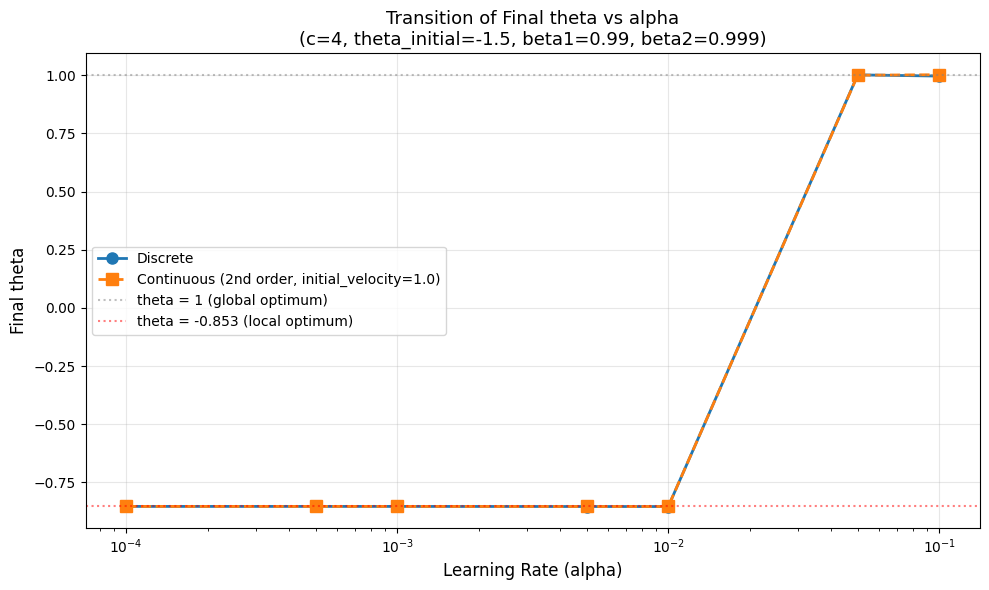

In [31]:
# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(alphas_discrete, theta_final_discrete, 'o-', label='Discrete', linewidth=2, markersize=8)
plt.plot(alphas_continuous, theta_final_continuous, 's--', label='Continuous (2nd order, initial_velocity=1.0)', linewidth=2, markersize=8)

plt.axhline(y=1, color='gray', linestyle=':', alpha=0.5, label='theta = 1 (global optimum)')
plt.axhline(y=-0.853, color='red', linestyle=':', alpha=0.5, label='theta = -0.853 (local optimum)')

plt.xlabel('Learning Rate (alpha)', fontsize=12)
plt.ylabel('Final theta', fontsize=12)
plt.title(f'Transition of Final theta vs alpha\n(c={c_value}, theta_initial={target_initial_theta}, beta1={target_beta1}, beta2={target_beta2})', fontsize=13)
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()